Total training images: 223414

Columns:
['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']

First few rows:
                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   
2  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
3  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
4  CheXpert-v1.0-small/train/patient00003/study1/...    Male   41   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP         1.0                         NaN           NaN   
1         Frontal    AP         NaN                         NaN          -1.0   
2    

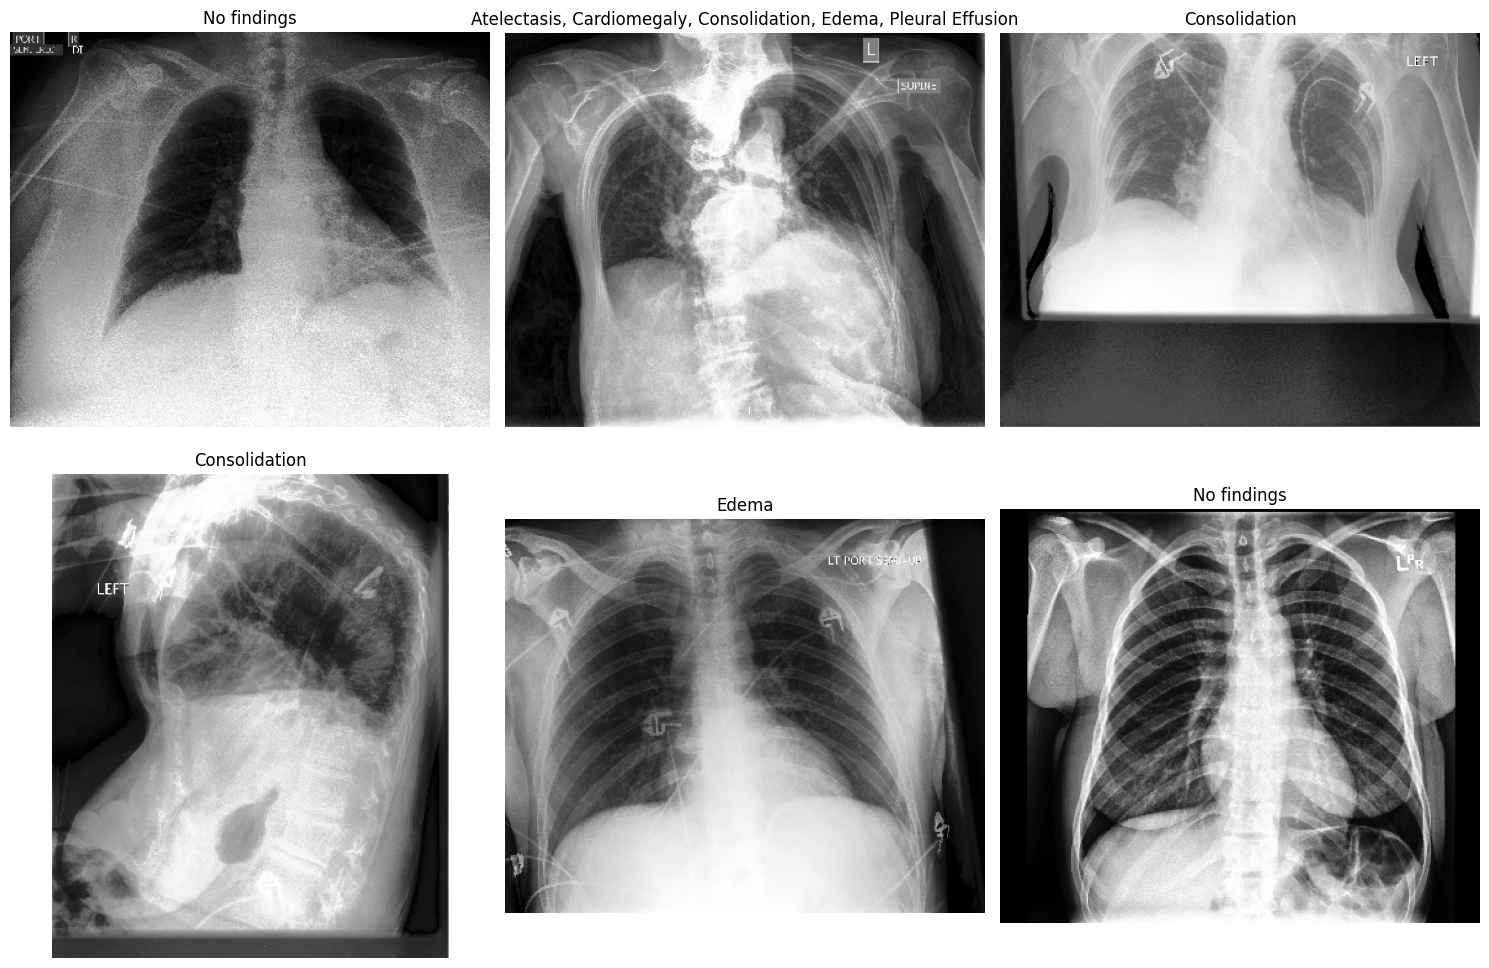

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os
import torch

train_df = pd.read_csv('../data/train.csv')

print(f"Total training images: {len(train_df)}")
print("\nColumns:")
print(train_df.columns.tolist())

print("\nFirst few rows:")
print(train_df.head())


train_df = pd.read_csv('../data/train.csv')
train_df = train_df.fillna(0)
train_df = train_df.replace(-1.0, 1.0)

# Fix path — strip the CheXpert-v1.0-small/ prefix
train_df["Path"] = train_df["Path"].str.replace("CheXpert-v1.0-small/", "", regex=False)


disease_cols = [
    'Atelectasis', 
    'Cardiomegaly', 
    'Consolidation', 
    'Edema', 
    'Pleural Effusion'
]

print("\nDisease distribution:")
for disease in disease_cols:
    positive = (train_df[disease] == 1.0).sum()
    print(f"{disease}: {positive} positive cases")


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(6):
    img_path = train_df.iloc[i]['Path']
    
    # Fix path from CSV → your folder structure
    img_path = img_path.replace("CheXpert-v1.0-small/", "")
    
    # Correct relative path (since notebook is in models/)
    full_path = os.path.join("../data", img_path)
    
    print("Opening:", full_path)
    
    try:
        img = Image.open(full_path).convert("L")  # grayscale
        
        axes[i].imshow(img, cmap='gray')
        
        # Get diseases for this image
        diseases = []
        for disease in disease_cols:
            if train_df.iloc[i][disease] == 1.0:
                diseases.append(disease)
        
        title = ', '.join(diseases) if diseases else 'No findings'
        axes[i].set_title(title)
        axes[i].axis('off')
    
    except Exception as e:
        print(f"Error loading image: {e}")
        axes[i].set_title("Error")
        axes[i].axis('off')

plt.tight_layout()
plt.show()

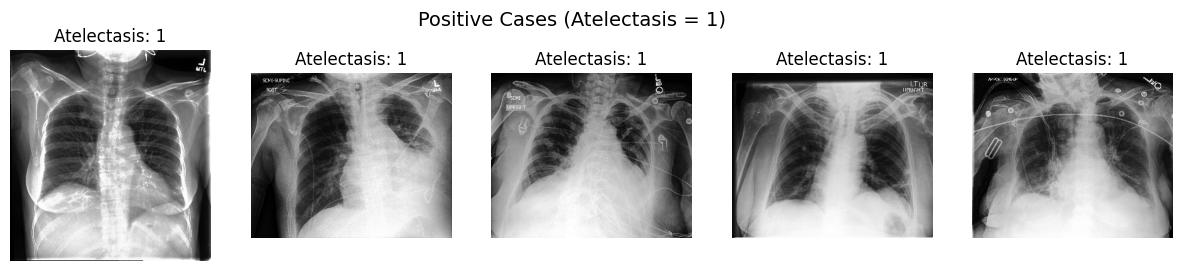

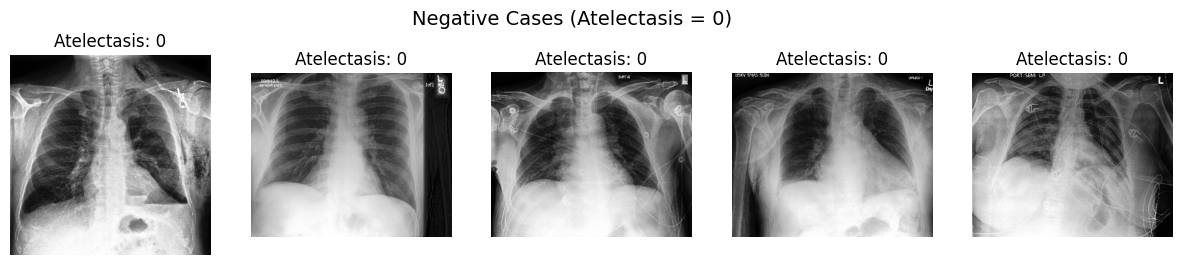

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Select samples
pos_samples = train_df[train_df["Atelectasis"] == 1].sample(5, random_state=42)
neg_samples = train_df[train_df["Atelectasis"] == 0].sample(5, random_state=42)

# Root directory (adjust if needed)
root_dir = "../data"   # change to "data" if notebook is in root

def show_samples(samples, title):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=14)

    for i, (_, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(
            root_dir,
            row["Path"].replace("CheXpert-v1.0-small/", "")
        )

        img = Image.open(img_path).convert("RGB")

        plt.subplot(1, len(samples), i + 1)
        plt.imshow(img)
        plt.title(f"Atelectasis: {int(row['Atelectasis'])}")
        plt.axis("off")

    plt.show()

# Display
show_samples(pos_samples, "Positive Cases (Atelectasis = 1)")
show_samples(neg_samples, "Negative Cases (Atelectasis = 0)")

In [3]:
import pandas as pd

# Assuming train_df already loaded
class_counts = {}

for col in disease_cols:
    positive = (train_df[col] == 1).sum()
    negative = (train_df[col] == 0).sum()
    
    class_counts[col] = {
        "positive": int(positive),
        "negative": int(negative),
        "total": int(positive + negative),
        "pos_ratio": float(positive / (positive + negative)),
        "pos_weight": float(negative / positive)
    }

# Convert to DataFrame for easy viewing
class_counts_df = pd.DataFrame(class_counts).T
print(class_counts_df)

                  positive  negative     total  pos_ratio  pos_weight
Atelectasis        67115.0  156299.0  223414.0   0.300406    2.328824
Cardiomegaly       35087.0  188327.0  223414.0   0.157049    5.367430
Consolidation      42525.0  180889.0  223414.0   0.190342    4.253710
Edema              65230.0  158184.0  223414.0   0.291969    2.425019
Pleural Effusion   97815.0  125599.0  223414.0   0.437819    1.284046


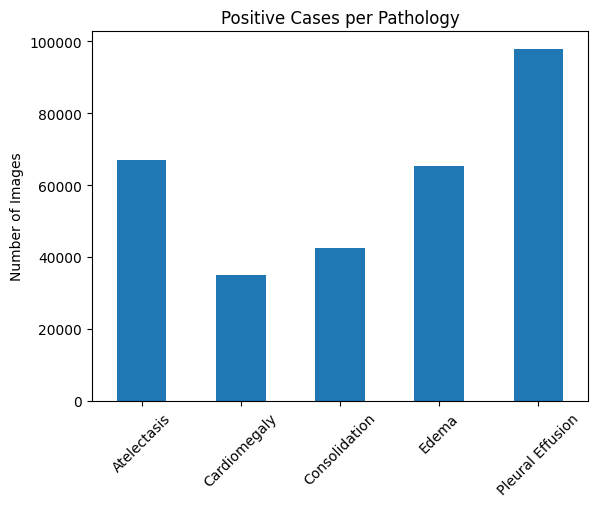

In [4]:
import matplotlib.pyplot as plt

class_counts_df["positive"].plot(kind='bar')
plt.title("Positive Cases per Pathology")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [5]:
print(train_df.columns)
print(train_df.head())


Index(['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding',
       'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices'],
      dtype='str')
                                          Path     Sex  Age Frontal/Lateral  \
0  train/patient00001/study1/view1_frontal.jpg  Female   68         Frontal   
1  train/patient00002/study2/view1_frontal.jpg  Female   87         Frontal   
2  train/patient00002/study1/view1_frontal.jpg  Female   83         Frontal   
3  train/patient00002/study1/view2_lateral.jpg  Female   83         Lateral   
4  train/patient00003/study1/view1_frontal.jpg    Male   41         Frontal   

  AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  Lung Opacity  \
0    AP         1.0                         0.0           0.0           0.0   
1    AP         0.0              

In [6]:
train_df["PatientID"] = train_df["Path"].apply(lambda x: x.split("/")[2])
print(train_df["PatientID"].head())

0    study1
1    study2
2    study1
3    study1
4    study1
Name: PatientID, dtype: str


In [7]:
from sklearn.model_selection import train_test_split

patients = train_df["PatientID"].unique()

train_patients, temp_patients = train_test_split(
    patients,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [8]:
train_data = train_df[train_df["PatientID"].isin(train_patients)]
val_data   = train_df[train_df["PatientID"].isin(val_patients)]
test_data  = train_df[train_df["PatientID"].isin(test_patients)]

In [9]:
print(len(train_data))
print(len(test_data))
print(len(val_data))

print(
    set(train_data["PatientID"]) & set(val_data["PatientID"]),
    set(train_data["PatientID"]) & set(test_data["PatientID"]),
    set(val_data["PatientID"]) & set(test_data["PatientID"])
)

94335
118526
10553
set() set() set()


In [10]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class CheXpertDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform
        self.label_cols = [
            "Atelectasis",
            "Cardiomegaly",
            "Consolidation",
            "Edema",
            "Pleural Effusion"
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_root, row["Path"])
        image = Image.open(img_path).convert("RGB")

        labels = torch.tensor(row[self.label_cols].values.astype("float32"))

        if self.transform:
            image = self.transform(image)

        return image, labels

In [11]:
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import time

raw_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

raw_dataset = CheXpertDataset(train_data, image_root="../data", transform=raw_transform)

In [12]:
mean = [0.5330, 0.5330, 0.5330]
std  = [0.0349, 0.0349, 0.0349]
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [14]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, 5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using: {device}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\amsah/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%


Using: cuda
